## Black Scholes Model

The *Black Scholes* model was published in 1973 for non-dividend paying stocks and since then the model has created a revolution in quantitative finance and opened up derivatives pricing paradigm. Black Scholes model is based on number of assumptions about how financial markets operate and those are:

* Arbitrage Free Markets
* Frictionless and Continuous Markets
* Risk Free Rates
* Log-normally Distributed Price Movements
* Constant Volatility

These assumptions maynot hold true in reality, but are not particularly limiting. The generalized Black Scholes framework have been extended to price derivaties of other asset classes such as Black 76 (Commodity Futures) and Garman-Kohlhagen (FX Futures) that are currently used in derivative pricing and risk management.

### Black Scholes Formula
The Black–Scholes equation describes the price of the option over time as

$$
\frac{\partial V}{\partial t}
+ \frac 1{2}{\sigma^2 S^2} \frac{\partial^2 V}{\partial S^2}
+ r S \frac{\partial V}{\partial S} - rV = 0 
$$

<br>Solving the above equation, we know that the value of a call option for a non-dividend paying stock is:<br>

$$ C = SN(d_1) - Ke^{-rt}N(d_2) $$

and, the corresponding put option price is:

$$ P = Ke^{-rt}N(-d_2) - SN(-d_1)$$

where, 

$$ d_1= \frac{1}{\sigma \sqrt{t}}\left[\ln{\left(\frac{S}{K}\right)} +{\left(r + \frac{\sigma^2}{2}\right)}t\right] $$
<br>

$$ d_2= d_1 - \sigma \sqrt{t} $$
<br>

$$ N(x)=\frac{1}{\sqrt{2\pi}} \int_{-\infty}^{x} \mathrm e^{-\frac{1}{2}x^2} dx $$


$S$ is the spot price of the underlying asset<br>
$K$ is the strike price<br>
$r$ is the annualized continuous compounded risk free rate<br>
$\sigma$ is the volatility of returns of the underlying asset<br>
$t$ is time to maturity (expressed in years)<br>
$N(x)$ is the standard normal cumulative distribution

### Greeks

| **Description** |  | **Greeks for Call Option** | **Greeks for Put Option**             
|:-----------|:----------------|:----------------|:--------                                                                                                       
| **Delta**  |$ \space\space \frac {\partial V}{\partial S}$ Sensitivity of Value to changes in price | $N(d_1)$ | $-N(-d_1)$
| **Gamma**  |$ \space\space \frac {\partial ^{2}V}{\partial S^{2}}$ Sensitivity of Delta to changes in price | $\frac{N'(d_1)}{S\sigma\sqrt{t}}$
| **Vega**   |$ \space\space \frac {\partial V}{\partial \sigma}$ Sensitivity of Value to changes in volatility | $SN'(d_1)\sqrt{t}$
| **Theta**  |$ \space\space \frac {\partial V}{\partial t}$ Sensitivity of Value to changes in time | $-\frac{SN'(d_1)\sigma}{2\sqrt{t}}-rKe^{-rt}N(d_2)$ | $-\frac{SN'(d_1)\sigma}{2\sqrt{t}}+rKe^{-rt}N(-d_2)$
| **Rho**    |$ \space\space \frac {\partial V}{\partial r}$  Sensitivity of Value to changes in risk-free | $Kte^{-rt}N(d_2)$ | $-Kte^{-rt}N(-d_2)$

### Example
We will now price a European call option of an asset maturing in the next 144 days with the following specifications:

* $S$ = 330
* $K$ = 335
* $r$ = 2\%
* $\sigma$ = 20\%
* $t$ = 0.3945

*What price should you pay (per unit) for the option contract?*

$\mathrm d_1= \frac{1}{0.20 \sqrt{0.3945}} \left[\ln{\left(\frac{330}{335}\right)} + 0.3945\left(0.02 + \frac{0.20^2}{2} \right) \right]=0.00590775$


$\mathrm d_2= d_1 - {0.20 \sqrt{0.3945}}=-0.11971071$

Now that we've calculated $d_1$ and $d_2$, we then evaluate
$N(d_1)=N(0.00590775)=0.50235683$

$N(d_2)=N(-0.11971071)=0.45235615$

Next, we plug these values in the above equation to calculate the price of the call option.

$C(330,0.3945)= (0.50234683)(330) - (0.45235615)(335) \space \mathrm e^{-(0.02)(0.3945)} \approx 15.4294$

Thus, we will be paying around \$1542.94 for the options contract with a lot size or multiplier of 100 units.

### Import Required Libraries

In [29]:
# Base libraries
import numpy as np
import pandas as pd
from typing import Tuple
from scipy.stats import norm

# Plotting
import matplotlib.pyplot as plt
from tabulate import tabulate

### Options Object
Python is an object oriented programming language.  Almost everything in Python is an object, with its properties and methods. There are two common programming paradigm in Python.

>1. Procedural Programming
>2. Object-oriented Programming (OOP)

The key difference between them is that in OOP, objects are at the center, not only representing the data, as in the procedural programming, but in the overall structure of the program as well.

### Class
We use Classes to create user-defined data structures. Classes define functions called methods, which identify the characteristics and actions that an object created from the class can perform with its data. A Class is like an object constructor, or a "blueprint" for creating objects. To create a class, use the keyword **class**

#### \_\_init\_\_

The properties of the class objects are defined in a method called $\_\_init\_\_$

>1. \_\_init\_\_() sets the initial state of the object by assigning the values of the object’s properties. 
>2. \_\_init\_\_() initializes each new instance of the class
>3. Attributes created in \_\_init\_\_() are called instance attributes, while class attributes are attributes that have the same value for all class instances.

#### self

The *self* is a parameter used to represent the instance of the class. With self, you can access the attributes and methods of the class in python. It binds the attributes with the given arguments. When a new class instance is created, the instance is automatically passed to the self parameter in \_\_init\_\_() so that new attributes can be defined on the object.

>1. \_\_init\_\_() can have any number of parameters, but the first parameter will always be a variable called self.

We will now construct a Black Scholes Options class

In [30]:
class BS:
    def __init__(self, spot, strike, rate, dte, volatility):
        self.S = spot
        self.K = strike
        self.r = rate
        self.t = dte
        self.sigma = volatility
        
        # Calculate common terms used across methods
        self.time_sqrt = np.sqrt(self.t)
        self.discount_factor = np.exp(-self.r * self.t)
       
        # Calculate d1 and d2 parameters
        self.d1 = self._calculate_d1()
        self.d2 = self.d1 - self.sigma * self.time_sqrt
        
        # Calculate all option Greeks and prices
        self.call_price, self.put_price = self._price()
        self.call_delta, self.put_delta = self._delta()
        self.gamma = self._gamma()
        self.vega = self._vega()
        self.call_theta, self.put_theta = self._theta()
        self.call_rho, self.put_rho = self._rho()
       
    def _calculate_d1(self) -> float:
        return (np.log(self.S / self.K) + (self.r + (self.sigma**2) / 2) * self.t) / (
            self.sigma * self.time_sqrt
        )
    
    def _price(self) -> Tuple[float, float]:
        d1_cdf = norm.cdf(self.d1)
        d2_cdf = norm.cdf(self.d2)

        call = self.S * d1_cdf - self.K * self.discount_factor * d2_cdf
        put = self.K * self.discount_factor * norm.cdf(-self.d2) - self.S * norm.cdf(
            -self.d1
        )
        return call, put
    
    def _delta(self) -> Tuple[float, float]:
        d1_cdf = norm.cdf(self.d1)
        return d1_cdf, -norm.cdf(-self.d1)
    
    def _gamma(self) -> float:
        return norm.pdf(self.d1) / (self.S * self.sigma * self.time_sqrt)
    
    def _vega(self) -> float:
        return self.S * norm.pdf(self.d1) * self.time_sqrt / 100
    
    def _theta(self) -> Tuple[float, float]:
        spot_term = -self.S * norm.pdf(self.d1) * self.sigma / (2 * self.time_sqrt)
        call_rate_term = -self.r * self.K * self.discount_factor * norm.cdf(self.d2)
        put_rate_term = self.r * self.K * self.discount_factor * norm.cdf(-self.d2)

        return (spot_term + call_rate_term) / 365, (spot_term + put_rate_term) / 365
    
    def _rho(self) -> Tuple[float, float]:
        call = self.K * self.t * self.discount_factor * norm.cdf(self.d2) / 100
        put = -self.K * self.t * self.discount_factor * norm.cdf(-self.d2) / 100
        return call, put

In [31]:
# Initialize option
option = BS(100,100,0.05,1,0.2)

header = ['Type', 'Option Price', 'Delta', 'Gamma', 'Theta', 'Vega', 'Rho']
table = [
    [
        'Call',
        option.call_price,
        option.call_delta,
        option.gamma,
        option.call_theta,
        option.vega,
        option.call_rho
    ],
    [   
        'Put',
        option.put_price,
        option.put_delta,
        option.gamma,
        option.put_theta,
        option.vega,        
        option.put_rho       
    ],
]

print(tabulate(table,header))

Type      Option Price      Delta     Gamma        Theta     Vega        Rho
------  --------------  ---------  --------  -----------  -------  ---------
Call          10.4506    0.636831  0.018762  -0.0175727   0.37524   0.532325
Put            5.57353  -0.363169  0.018762  -0.00454214  0.37524  -0.418905


### Visualize the Payoff

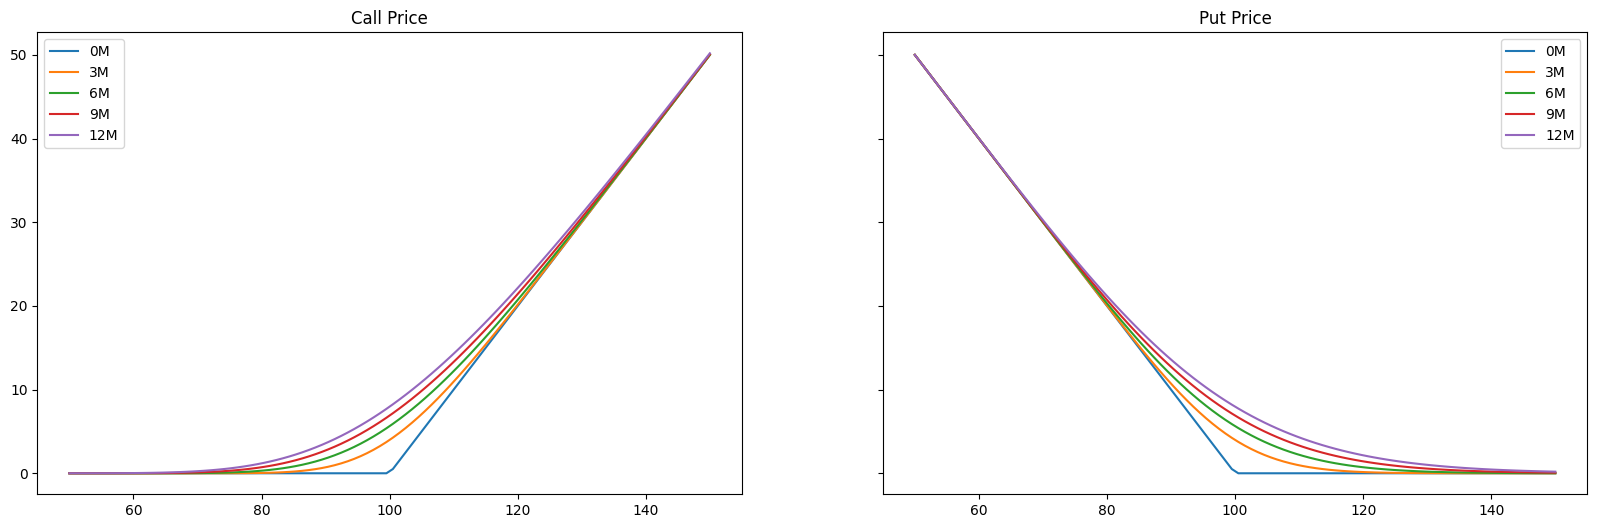

In [32]:
# Plot option values for range of spot prices over differece time
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Define expirations and labels
d = {'0M': 1e-50, '3M': 0.25, '6M': 0.5, '9M': 0.75, '12M': 1.0}
x = np.linspace(50, 150, 100)

# Plot call and put prices
for label, tau in d.items():
    bs = BS(x, 100, 0.0, tau, 0.2)
    axes[0].plot(x, bs.call_price, label=label)
    axes[1].plot(x, bs.put_price, label=label)

# Set titles and legends
for ax, title in zip(axes, ["Call Price", "Put Price"]):
    ax.set_title(title)
    ax.legend()

plt.show()


### Visualize the Greeks

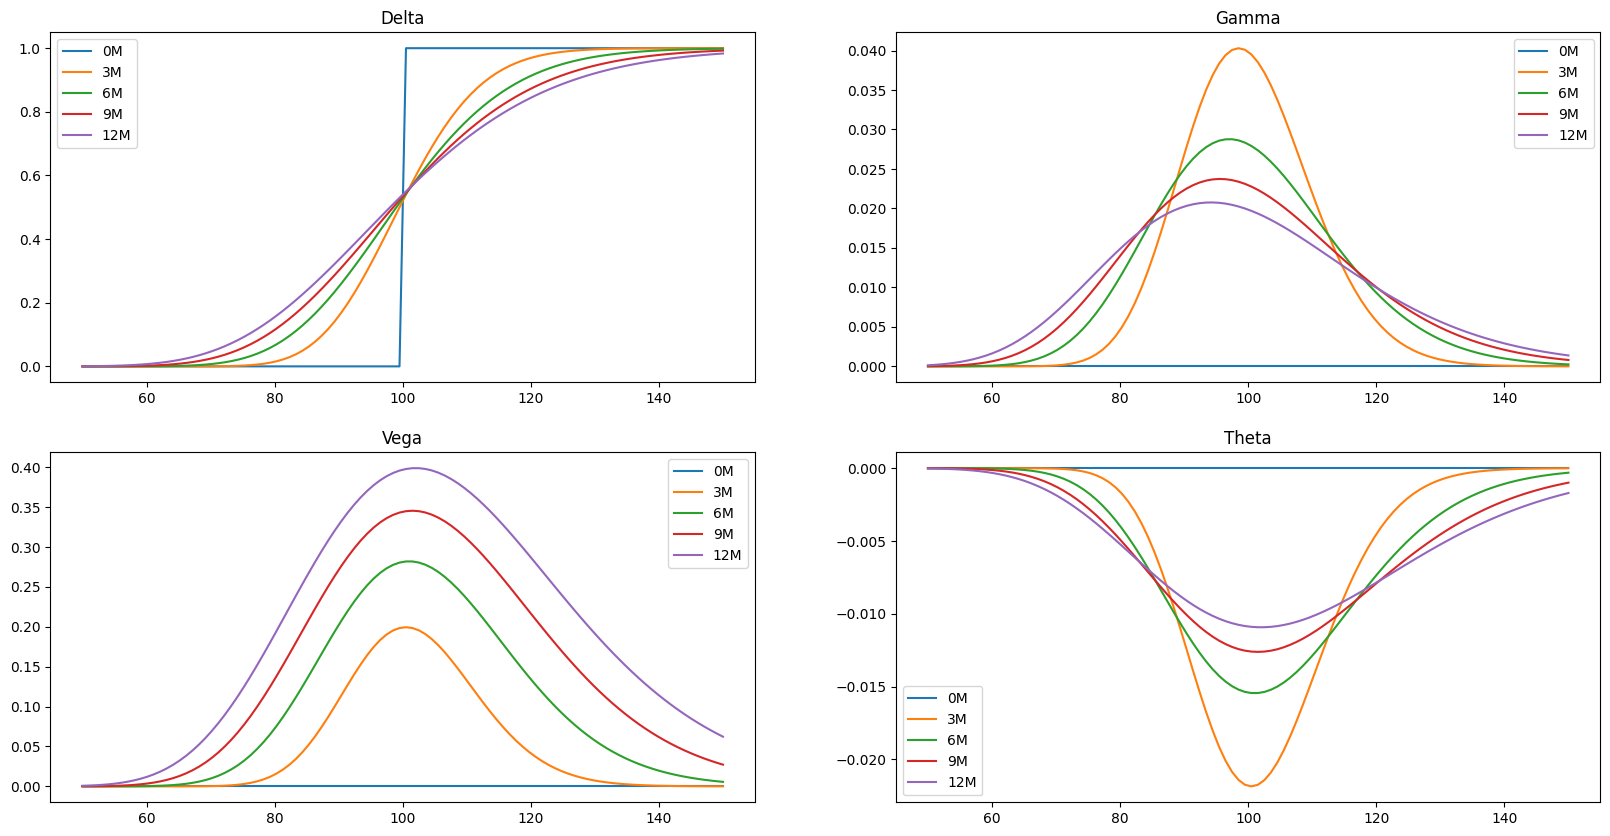

In [33]:
# Plot graph iteratively
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

# Define Greeks and their respective subplot positions
greeks = {
    (0, 0): ('call_delta', 'Delta'),
    (0, 1): ('gamma', 'Gamma'),
    (1, 0): ('vega', 'Vega'),
    (1, 1): ('call_theta', 'Theta')
}

# Plot all Greeks in one loop
for (i, j), (attr, title) in greeks.items():
    for label, tau in d.items():
        ax[i, j].plot(x, getattr(BS(x, 100, 0.0, tau, 0.2), attr), label=label)
    ax[i, j].set_title(title)
    ax[i, j].legend()

plt.show()



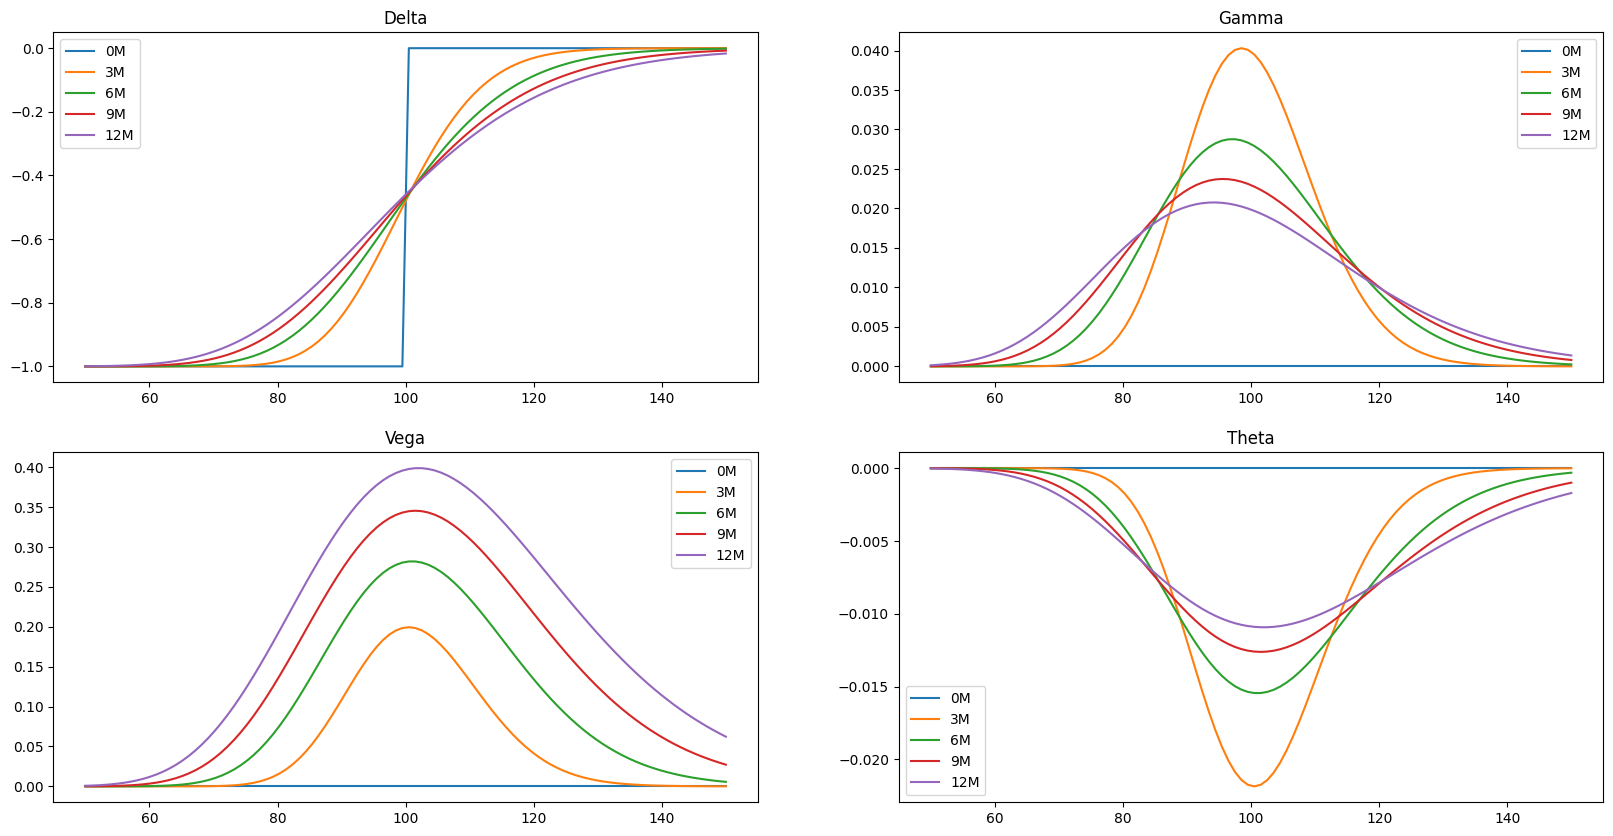

In [34]:
# Plot graph iteratively
fig, ax = plt.subplots(2, 2, figsize=(20, 10))

# Define Greeks and their respective subplot positions
greeks = {
    (0, 0): ('put_delta', 'Delta'),
    (0, 1): ('gamma', 'Gamma'),
    (1, 0): ('vega', 'Vega'),
    (1, 1): ('put_theta', 'Theta')
}

# Plot all Greeks in one loop
for (i, j), (attr, title) in greeks.items():
    for label, tau in d.items():
        ax[i, j].plot(x, getattr(BS(x, 100, 0.0, tau, 0.2), attr), label=label)
    ax[i, j].set_title(title)
    ax[i, j].legend()

plt.show()

## Nifty Option
Let's now retrieve NIFTY option data using the `quantmod` library and manipulate the dataframe with the Black-Scholes option pricing model that we previously created. You can retrieve the NIFTY option data from the following link: https://www.nseindia.com/get-quotes/derivatives?symbol=NIFTY&identifier=OPTIDXNIFTY13-03-2025CE22500.00

`Note`: You will need to update the quantmod library to version 0.0.6 to use Indian options data.

https://kannansingaravelu.com/quantmod/index.html

In [11]:
# update quantmod to version 0.0.6 for NSE options
from quantmod.derivatives import OptionData
from datetime import datetime, timedelta
from quantmod.models import OptionInputs, BlackScholesOptionPricing
import pandas as pd

In [23]:
# Get option chain for specify expiry
expiration = '24-Apr-2025'
valuation = datetime.today()
ttm = (pd.to_datetime(expiration+' 15:30:00') - pd.to_datetime(valuation)) / timedelta(days=365)

# Instantiate the Option Data
opt = OptionData("NIFTY", expiration)
df = opt.get_call_option_data
df.head(2)

,strikePrice,expiryDate,underlying,identifier,openInterest,changeinOpenInterest,pchangeinOpenInterest,totalTradedVolume,impliedVolatility,lastPrice,change,pChange,totalBuyQuantity,totalSellQuantity,bidQty,bidprice,askQty,askPrice,underlyingValue
0,20350,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE20350.00,93,0,0.0,0,0.0,3408.75,2.4,0.070457,5325,3450,75,3234.80,1725,3371.55,23519.35
1,20400,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE20400.00,20,0,0.0,0,0.0,3427.30,0.4,0.011672,5325,3600,75,3190.25,150,3250.00,23519.35


In [24]:
df.tail(2)

,strikePrice,expiryDate,underlying,identifier,openInterest,changeinOpenInterest,pchangeinOpenInterest,totalTradedVolume,impliedVolatility,lastPrice,change,pChange,totalBuyQuantity,totalSellQuantity,bidQty,bidprice,askQty,askPrice,underlyingValue
102,25450,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE25450.00,378,-45,-10.638298,1051,13.43,8.45,-2.35,-21.759259,50475,11550,375,7.85,225,8.85,23519.35
103,25500,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE25500.00,22169,2682,13.763022,26571,13.61,8.00,-1.05,-11.602210,114300,102750,2025,8.00,225,8.25,23519.35


### Query Option Chain

In [25]:
# querry strikes between 22000 and 22500
df = df.query('strikePrice>=22500 and strikePrice<=25000').reset_index(drop=True)
df.head()

,strikePrice,expiryDate,underlying,identifier,openInterest,changeinOpenInterest,pchangeinOpenInterest,totalTradedVolume,impliedVolatility,lastPrice,change,pChange,totalBuyQuantity,totalSellQuantity,bidQty,bidprice,askQty,askPrice,underlyingValue
0,22500,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE22500.00,18107,352,1.982540,4168,0.00,1174.15,-129.55,-9.937102,12000,13425,375,1172.65,150,1185.75,23519.35
1,22550,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE22550.00,418,-2,-0.476190,8,8.48,1138.55,-159.45,-12.284284,3675,5625,225,956.70,225,1152.90,23519.35
2,22600,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE22600.00,1488,-128,-7.920792,466,0.00,1083.85,-118.80,-9.878186,3000,5925,75,1073.65,75,1098.50,23519.35
3,22650,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE22650.00,461,0,0.000000,1,0.00,955.00,-211.80,-18.152211,5475,3675,75,1019.35,225,1063.75,23519.35
4,22700,24-Apr-2025,NIFTY,OPTIDXNIFTY24-04-2025CE22700.00,2507,-248,-9.001815,491,7.23,989.00,-126.65,-11.352127,7800,6600,75,978.65,75,1004.65,23519.35


### Option Analysis

In [26]:
# Dataframe manipulation with selected fields
df1 = pd.DataFrame({'Strike': df['strikePrice'],
                    'Price': df['lastPrice'],
                    })

# Instantiate BS Pricing Engine from quantmod and Derive Implied Volatiliy
for i in range(len(df1)):
    nifty = BlackScholesOptionPricing(
        OptionInputs(
            spot = 22400,
            strike = df1['Strike'].iloc[i], 
            rate = 0.0,
            ttm = ttm,
            volatility = 0.20,
            callprice = df1['Price'].iloc[i]
            )
        )
        
    df1.loc[i, 'ImpVol'] = nifty.impvol
    
# Check output
df1.head(10)

,Strike,Price,ImpVol
0,22500,1174.15,0.540316
1,22550,1138.55,0.534667
2,22600,1083.85,0.520431
3,22650,955.00,0.473240
4,22700,989.00,0.497940
5,22750,939.25,0.485413
6,22800,900.35,0.477515
7,22850,860.45,0.468987
8,22900,811.90,0.456402
9,22950,755.25,0.439948


In [35]:
# Derive greeks and assign to dataframe as columns
for i in range(len(df1)):
    # initializing the BS option object
    nifty = BS(
        spot = 22400, 
        strike = df1['Strike'].iloc[i], 
        rate = 0.0,
        dte = ttm, 
        volatility=df1['ImpVol'].iloc[i]
        )
    # assign greeks to dataframe 
    df1.loc[i, 'Delta'] = nifty.call_delta
    df1.loc[i, 'Gamma'] = nifty.gamma
    df1.loc[i, 'Vega'] = nifty.vega
    df1.loc[i, 'Theta'] = nifty.call_theta
    
# Verify output
df1.head(10)

,Strike,Price,ImpVol,Delta,Gamma,Vega,Theta
0,22500,1174.15,0.540316,0.514270,0.000130,22.596889,-26.123812
1,22550,1138.55,0.534667,0.507304,0.000132,22.607565,-25.862896
2,22600,1083.85,0.520431,0.499338,0.000135,22.611324,-25.178444
3,22650,955.00,0.473240,0.486910,0.000149,22.599182,-22.883087
4,22700,989.00,0.497940,0.483011,0.000141,22.590850,-24.068526
5,22750,939.25,0.485413,0.474159,0.000145,22.563902,-23.435061
6,22800,900.35,0.477515,0.465702,0.000147,22.527743,-23.016788
7,22850,860.45,0.468987,0.456887,0.000149,22.479189,-22.557001
8,22900,811.90,0.456402,0.446930,0.000153,22.410992,-21.885090
9,22950,755.25,0.439948,0.435556,0.000158,22.315700,-21.006419


### Visualize

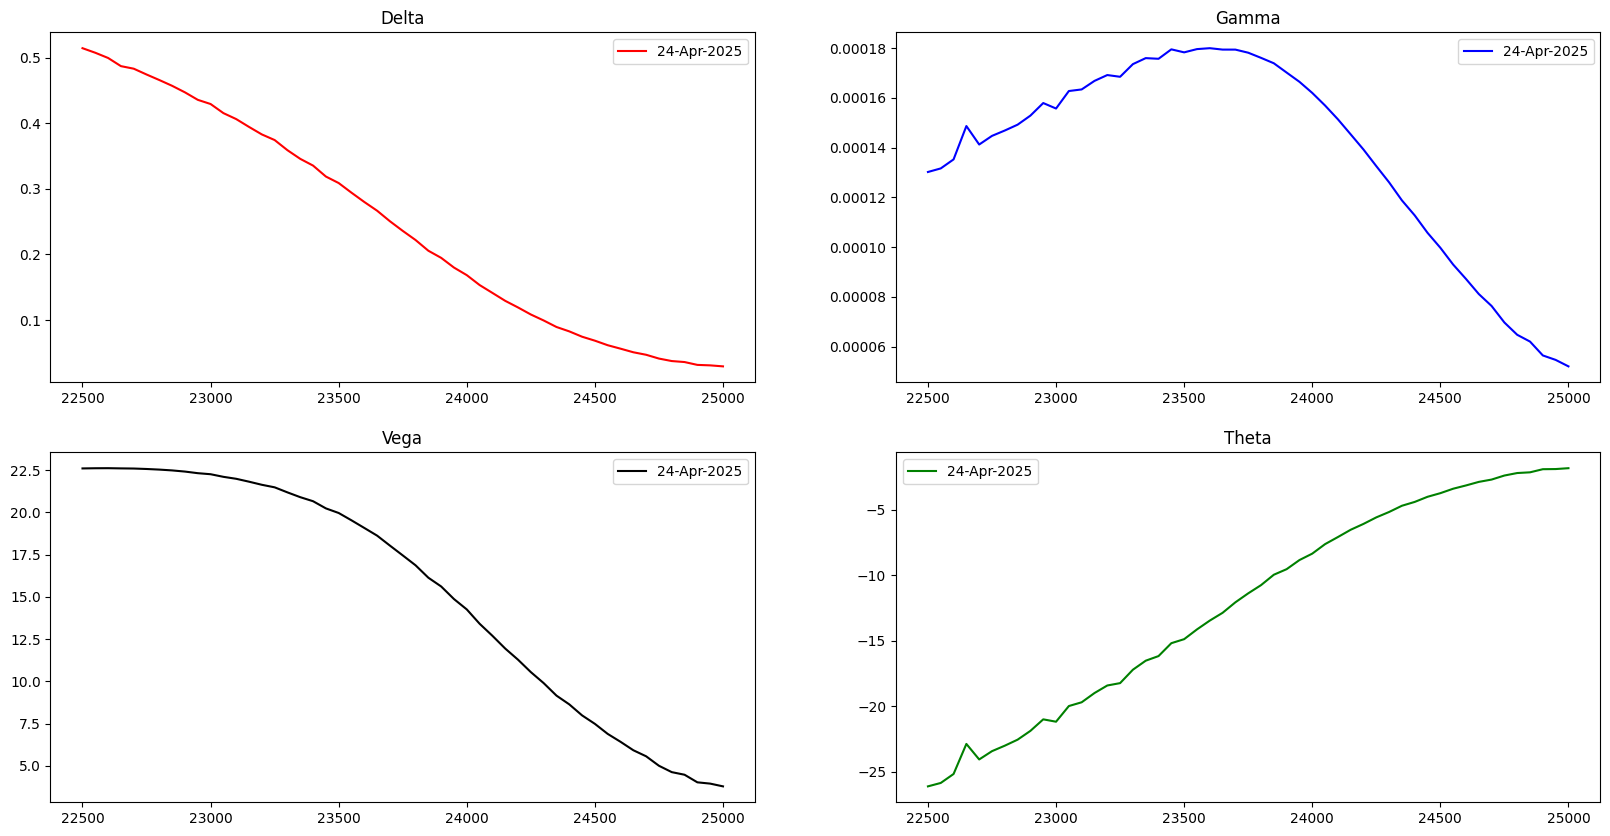

In [36]:
# Plot graph iteratively
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

# Greek parameters
greeks = {
    (0,0): ('Delta', 'r'),
    (0,1): ('Gamma', 'b'),
    (1,0): ('Vega', 'k'),
    (1,1): ('Theta', 'g')
}

# Plot all greeks in one loop
for (i,j), (greek, color) in greeks.items():
    axes[i,j].plot(df1['Strike'], df1[greek], color=color, label=expiration)
    axes[i,j].set_title(greek)
    axes[i,j].legend()

plt.show()

## References

* [Matplotlib](https://matplotlib.org)
* [Python Class Reference](https://docs.python.org/3/tutorial/classes.html)
* [Python Resources](https://github.com/kannansingaravelu/PythonResources)
* [Quantmod Documentation](https://kannansingaravelu.com/quantmod)